# Stellar-Age BNN (RGB): load → select → normalize → train → calibrate

End-to-end pipeline training on the **all-missions merged catalog with Willett
ages** (`merged_with_ages_raw.parquet`) — the same source dataset as the Cannon
notebook (`AnniesLasso/notebooks/train_rgb_wilett_all_missions.ipynb`). All
selection and normalization happens here, just before training; no pre-baked
BNN CSV to regenerate when the upstream catalog changes.

1. **Load & select** via `prep.load_willett_merged`: the Cannon notebook's cuts
   (finite `age_L`, ASPCAP sentinels, `RelAge_L`, young-α-rich impostors), RGB
   state from seismic `EvoState` (optionally extended to K2/TESS via
   `SELECTION_FILE`), Astra `raw_*` columns mapped to the BNN convention. Then
   dedup, drop unphysical ages, and a **stratified** train/val/test split on
   logAge bins (persisted to `split_assignments.csv`).
2. **Normalize** — derive `[C/N]` and Salaris `[M/H]`, standardize with
   **train-only** statistics (no leakage). Includes a young-tail label audit.
3. **Train** the robust BNN with input-uncertainty propagation, minibatch-correct
   ELBO scaling, and a tightened global intrinsic-scatter prior.
4. **Calibrate** on the val split (robust σ factor + inverse-calibration
   de-shrinkage), then **evaluate once** on the held-out test split, with
   ridge/kNN/GBT baselines and σ-informativeness diagnostics.
5. **Verify & record** — round-trip the saved inference bundle through the exact
   reload path `predict_bulge_ages.py` uses, and write a `run_manifest.json`.

Designed to run on Gadi (or anywhere the repo + dataset live).

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# The repo holding prepare_dataset.py / train_bnn.py is located in the next cell.

In [2]:

CANDIDATES = [
    '~/scr_mk27/bingo-modern',
    '~/code/bingo-modern',
    '.',
]
repo = next((p for p in map(os.path.expanduser, CANDIDATES)
             if os.path.isfile(os.path.join(p, 'prepare_dataset.py'))), None)
if repo is None:
    raise FileNotFoundError('Could not find prepare_dataset.py. Add its dir to CANDIDATES.')
repo = os.path.abspath(repo)
os.chdir(repo)
sys.path.insert(0, repo)
print('repo:', repo)

import prepare_dataset as prep
from train_bnn import (
    set_seed,
    BayesianNeuralNetwork,
    train_smooth_bnn,
    get_targeted_posterior_samples,
    analyze_targeted_results,
    device,
)
print(f'Using device: {device}')

repo: /home/100/mj8805/scr_mk27/bingo-modern
Using device: cuda
Using device: cuda


## 2. Configuration

In [ ]:
# All-missions merged catalog with Willett ages -- the SAME source dataset the
# Cannon notebook (AnniesLasso/notebooks/train_rgb_wilett_all_missions.ipynb)
# trains from. Selection + normalization happen in THIS notebook, just before
# training, so there is no separate dataset-preparation step to keep in sync.
DATASET = '~/scr_mk27/bulge-ages-and-orbits/data/merged_with_ages_raw.parquet'

# Optional: reuse the Cannon notebook's spectra-based RGB selection for the
# K2/TESS stars that carry no seismic EvoState. Persist it from that notebook
# (ID column + boolean is_rgb) and point to it here; None = seismic-only.
SELECTION_FILE = None

OUTPUT_DIR = Path('./BNN_targeted_output_RGB')
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
TEST_FRAC = 0.20         # held-out fraction, touched exactly once (section 7)
VAL_FRAC = 0.15          # tuning + uncertainty-calibration split (never trained on)
SEED = 42
NUM_ITERATIONS = 20000
BATCH_SIZE = 32
HIDDEN_DIM = 32          # if val ELBO still trails the GBT/kNN baselines after the
                         # LR change below, try 64 next -- or let the PBS sweep
                         # (sweep_rgb_bnn.py) decide
INITIAL_LR = 0.0025      # halved from 0.005: the previous run showed violent
                         # late-training loss spikes and early-stopped at epoch
                         # 65/173; a calmer trajectory usually stops later and better
LR_DECAY_PER_EPOCH = 0.995  # ~0.5x LR over ~140 epochs; set 1.0 for constant LR
WEIGHT_CLIP = 10.0       # max inverse-frequency weight ratio (was 3.0). Unclipped
                         # imbalance is ~150x, so 3.0 left the young bins at ~1/50
                         # of balanced weight and the model ignored the young tail.
                         # Review the label audit (section 4) before raising further:
                         # upweighting the tail also upweights any mislabeled star in it.

# Prior on the GLOBAL intrinsic scatter (dex). The old loose prior (0.1, 0.3)
# let the posterior escape to 0.317 dex -- a floor that makes near-the-mean
# predictions nearly free and starves the per-star variance network. Tightened
# so unexplained scatter is pushed into the heteroscedastic model_var instead.
INTRINSIC_PRIOR_SCATTER = 0.05
INTRINSIC_PRIOR_LOGSTD = 0.2

# Young-tail audit thresholds (section 4). The load step already drops the
# Cannon notebook's "young alpha-rich impostors" (age < 4 Gyr, [Mg/Fe] > 0.15,
# [C/N] > -0.2); the audit shows what survives that cut in the young tail.
YOUNG_LOGAGE = 0.1       # "young" threshold: logAge < 0.1 (< ~1.3 Gyr)
ALPHA_RICH_MGFE = 0.15   # [Mg/Fe] above this counts as alpha-rich

# Early stopping on the validation ELBO. Val is already held out for calibration
# (section 7); monitoring it during training lets us stop once it stops improving
# and rewind to the best checkpoint, so NUM_ITERATIONS becomes a ceiling rather
# than the exact run length. Set EARLY_STOPPING = False for the old fixed-length run.
EARLY_STOPPING = True
ES_PATIENCE = 8          # stop after this many consecutive evals with no improvement
ES_MIN_DELTA = 0.0       # min val-ELBO (nat) improvement that counts as progress
ES_EVAL_EVERY = 5        # evaluate the val ELBO every N epochs

# Features the model sees: base columns + engineered [C/N] and the Salaris
# alpha-corrected metallicity [M/H] (see prepare_dataset.derive_features).
FEATURES = prep.BASE_FEATURES + ['C_N', 'M_H']
FEATURE_COLS = [f'{f}_NORM' for f in FEATURES]
ERROR_COLS = [f'{f}_ERR_NORM' for f in FEATURES]
FEATURES

## 3. Load, select & split — straight from the merged catalog

`prep.load_willett_merged` reads `merged_with_ages_raw.parquet` (spectra columns
are never touched) and applies the **same selection as the Cannon notebook**
(`train_rgb_wilett_all_missions.ipynb`): finite Willett age, ASPCAP sentinel rows
dropped, `RelAge_L`-unreliable ages dropped, young-α-rich impostors dropped, then
RGB selection — seismic `EvoState` where it exists (Kepler), optionally extended
to K2/TESS via a persisted classifier selection (`SELECTION_FILE`). The Astra
`raw_*` columns are mapped to the BNN convention with propagated ratio errors.

Everything from here on (dedup, cleaning, split, normalization) happens in this
notebook just before training — there is no pre-baked BNN CSV to regenerate when
the upstream catalog changes.

Dedup keeps the highest-SNR row per star, so a re-export with repeat
observations cannot leak the same star across splits. Label cleaning (unphysical
>13.8 Gyr ages) runs **before** the split so the strata are exact.

The split is **stratified on logAge quantile bins** into train/val/test: the young
and old tails hold single-digit star counts, so a plain random split can leave
val/test with zero tail stars. Val is used for tuning and uncertainty calibration;
**test is touched exactly once**, in section 7. The realized membership is written
to `split_assignments.csv` — the seed alone does not pin the split (it also
depends on the exact catalog), and the saved file makes test-set integrity
auditable downstream.

In [ ]:
# Load + select from the merged all-missions catalog (Cannon-notebook cuts:
# finite age_L, sentinels, RelAge_L, impostors, RGB state). Returns the BNN
# column convention: BASE_FEATURES + errors, logAge/logAgeErr/age, APOGEE_ID, SNR.
df = prep.load_willett_merged(os.path.expanduser(DATASET),
                              target_state='rgb',
                              selection_file=SELECTION_FILE)
print(f'Selected {len(df)} RGB stars, {df.shape[1]} columns')

# Safety net: keep the highest-SNR row per star.
before = len(df)
df = (df.sort_values('SNR', ascending=False)
        .drop_duplicates(prep.ID_COL, keep='first')
        .reset_index(drop=True))
print(f'Deduplicated by {prep.ID_COL}: {before} -> {len(df)} stars')

# Clean labels BEFORE splitting (pure row filter, so no leakage): the strata below
# are then computed on exactly the surviving stars and the fractions are exact.
df, clean_rep = prep.clean_labels(df, 'full catalog', drop_saturated=True)
df = df.reset_index(drop=True)

# Stratified train/val/test split on logAge quantile bins (fixed seed).
rng = np.random.default_rng(SEED)
strata = pd.qcut(df[prep.TARGET], q=10, labels=False, duplicates='drop')
train_idx, val_idx, test_idx = [], [], []
for b in np.unique(strata):
    members = rng.permutation(np.flatnonzero(strata == b))
    n_test = int(round(TEST_FRAC * len(members)))
    n_val = int(round(VAL_FRAC * len(members)))
    test_idx.extend(members[:n_test])
    val_idx.extend(members[n_test:n_test + n_val])
    train_idx.extend(members[n_test + n_val:])
train = df.iloc[sorted(train_idx)].reset_index(drop=True)
val = df.iloc[sorted(val_idx)].reset_index(drop=True)
test = df.iloc[sorted(test_idx)].reset_index(drop=True)
print(f'Train: {len(train)}  |  Val: {len(val)}  |  Test: {len(test)}')

# Persist the realized split: the seed alone does not pin it (it also depends on
# the exact catalog), so downstream scripts audit membership from this file.
pd.concat([s[[prep.ID_COL]].assign(split=name)
           for name, s in [('train', train), ('val', val), ('test', test)]]
          ).to_csv(OUTPUT_DIR / 'split_assignments.csv', index=False)
print(f"Split membership saved to {OUTPUT_DIR / 'split_assignments.csv'}")
train.head()

## 4. Normalize

Derive `[C/N]` (with propagated error) and standardize with **train-only** statistics.
Val and test are transformed with the train statistics; the inverse-frequency age
weights are computed on train only. (Label cleaning already happened in section 3,
before the split.)

In [ ]:
# Dedup-before-split makes overlap impossible; verify rather than assume.
ids = {name: set(s[prep.ID_COL]) for name, s in [('train', train), ('val', val), ('test', test)]}
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    overlap = ids[a] & ids[b]
    assert not overlap, f'{len(overlap)} stars appear in both {a} and {b}'

# Engineer [C/N] (+ propagated error)
train = prep.derive_features(train)
val = prep.derive_features(val)
test = prep.derive_features(test)

# Fit normalization on TRAIN ONLY, then apply to all splits
stats = prep.fit_norm_stats(train, FEATURES)
train = prep.apply_norm(train, FEATURES, stats)
val = prep.apply_norm(val, FEATURES, stats)
test = prep.apply_norm(test, FEATURES, stats)

# Inverse-frequency sample weights to fight age imbalance (train only)
train, edges, _ = prep.add_sample_weights(train, prep.N_AGE_BINS, WEIGHT_CLIP)

print(f'\nTrain: {len(train)} | Val: {len(val)} | Test: {len(test)} stars')
train[FEATURE_COLS].describe()

In [7]:
prep.validate(train, test, FEATURES, edges)


VALIDATION REPORT

  TRAIN (logAge histogram, n=3678):
    [-0.89,-0.72)     4 
    [-0.72,-0.55)     6 
    [-0.55,-0.39)    12 
    [-0.39,-0.22)    36 #
    [-0.22,-0.05)    43 #
    [-0.05,+0.12)    87 ###
    [+0.12,+0.29)   196 ########
    [+0.29,+0.46)   395 ################
    [+0.46,+0.63)   664 ###########################
    [+0.63,+0.79)   876 ###################################
    [+0.79,+0.96)   975 ########################################
    [+0.96,+1.13)   384 ###############

  TEST (logAge histogram, n=1128):
    [-0.89,-0.72)     2 
    [-0.72,-0.55)     2 
    [-0.55,-0.39)     7 
    [-0.39,-0.22)     7 
    [-0.22,-0.05)    10 #
    [-0.05,+0.12)    36 ####
    [+0.12,+0.29)    56 #######
    [+0.29,+0.46)   115 ###############
    [+0.46,+0.63)   206 ############################
    [+0.63,+0.79)   273 #####################################
    [+0.79,+0.96)   289 ########################################
    [+0.96,+1.13)   124 #################

  TRAIN effe

### Young-tail label audit

A known failure mode for RGB age labels: **apparently-young α-rich stars** are
frequently mass-transfer/merger products — their current mass (which the age
derives from) is not their birth mass, so the "young" reference age is wrong,
while their [C/N] genuinely looks old.

The load step already drops the Cannon notebook's impostor definition (age < 4 Gyr,
[Mg/Fe] > 0.15, **and old-like [C/N] > −0.2**). This audit flags what *survives*
in the young tail: young α-rich stars whose [C/N] looks young (≤ −0.2). Those are
either genuinely young thick-disk-like stars or subtler contaminants — review the
flagged list before trusting (or upweighting) the young tail, and cross-check
their IDs against the worst-offender table in section 7.

In [ ]:
# Diagnostic only: flags and counts, drops nothing. The hard impostor cut
# (young + alpha-rich + old-like [C/N]) already ran inside load_willett_merged;
# what shows up here survived it. Test is excluded so its labels stay untouched.
audit = pd.concat([train.assign(_split='train'), val.assign(_split='val')],
                  ignore_index=True)
young = audit[prep.TARGET] < YOUNG_LOGAGE
arich = audit['MG_FE'] > ALPHA_RICH_MGFE
flagged = audit[young & arich]

print(f'Young (logAge < {YOUNG_LOGAGE}, < ~{10**YOUNG_LOGAGE:.1f} Gyr): '
      f'{int(young.sum())} stars in train+val')
print(f'  of which alpha-rich ([Mg/Fe] > {ALPHA_RICH_MGFE}): {len(flagged)} '
      f'({len(flagged) / max(int(young.sum()), 1):.0%}) <- survived the '
      'impostor cut; review before trusting the young tail')

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(audit.loc[~young, 'FE_H'], audit.loc[~young, 'MG_FE'],
           s=6, alpha=0.15, color='grey', label='logAge >= threshold')
ax.scatter(audit.loc[young & ~arich, 'FE_H'], audit.loc[young & ~arich, 'MG_FE'],
           s=28, color='tab:blue', label='young, alpha-normal')
ax.scatter(flagged['FE_H'], flagged['MG_FE'],
           s=34, color='crimson', label='young, alpha-RICH (suspect)')
ax.axhline(ALPHA_RICH_MGFE, color='k', ls=':', lw=1)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.set_title('Young-tail label audit (train + val)')
ax.legend()
plt.tight_layout()
plt.show()

if len(flagged):
    print('\nFlagged stars (review before believing -- or upweighting -- the young tail):')
    print(flagged[[prep.ID_COL, prep.TARGET, 'age', 'FE_H', 'MG_FE', '_split']]
          .sort_values(prep.TARGET).to_string(index=False))

## 5. Build tensors

In [ ]:
def to_arrays(d):
    X = d[FEATURE_COLS].values.astype(np.float32)
    X_err = d[ERROR_COLS].values.astype(np.float32)
    y = d[prep.TARGET].values.astype(np.float32)
    y_err = d[prep.TARGET_ERR].values.astype(np.float32)
    # Inverse-frequency age weights (mean 1). Val/test have no weights -> ones.
    w = (d['train_weight'].values if 'train_weight' in d.columns
         else np.ones(len(d))).astype(np.float32)
    return X, X_err, y, y_err, w


def to_tensor(a):
    return torch.as_tensor(a, dtype=torch.float32, device=device)


X_train, X_err_train, y_train, y_err_train, w_train = to_arrays(train)
X_val, X_err_val, y_val, y_err_val, _ = to_arrays(val)
X_test, X_err_test, y_test, y_err_test, _ = to_arrays(test)

print(f'Features: {X_train.shape[1]}  ({FEATURE_COLS})')
print(f'logAge range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'train_weight: mean={w_train.mean():.3f}, min={w_train.min():.3f}, max={w_train.max():.3f}')

X_train_t = to_tensor(X_train)
X_err_train_t = to_tensor(X_err_train)
y_train_t = to_tensor(y_train)
y_err_train_t = to_tensor(y_err_train)

# Validation tensors for early-stopping (monitored during training, section 6).
X_val_t = to_tensor(X_val)
X_err_val_t = to_tensor(X_err_val)
y_val_t = to_tensor(y_val)
y_err_val_t = to_tensor(y_err_val)

# Bare inverse-frequency weights (mean 1). The minibatch-correct ELBO scaling
# (likelihood x N/len(batch)) is applied inside train_smooth_bnn via
# minibatch_scale=True, using the actual batch length each step -- do NOT
# pre-multiply by N/BATCH_SIZE here.
w_train_t = to_tensor(w_train)

## 6. Train the network

In [ ]:
set_seed(SEED)

y_mean = float(np.mean(y_train))
y_std = float(np.std(y_train))
print(f'Empirical logAge stats - mean: {y_mean:.3f}, std: {y_std:.3f}')

MODEL_KWARGS = dict(
    input_dim=X_train.shape[1],
    hidden_dim=HIDDEN_DIM,
    use_skip_connections=True,
    use_empirical_output_bias=True,  # mean-zero bias prior: less shrinkage to y_mean
    use_leaky_relu=True,
    y_mean=y_mean,
    y_std=y_std,
    # Tightened global intrinsic-scatter prior: push unexplained scatter into
    # the per-star variance network instead of a global additive floor.
    intrinsic_scatter_prior=INTRINSIC_PRIOR_SCATTER,
    intrinsic_scatter_prior_logstd=INTRINSIC_PRIOR_LOGSTD,
)
model = BayesianNeuralNetwork(**MODEL_KWARGS)
model.to(device)

guide, losses = train_smooth_bnn(
    model,
    X_train_t, X_err_train_t,
    y_train_t, y_err_train_t,
    num_iterations=NUM_ITERATIONS,
    initial_lr=INITIAL_LR,
    lr_decay_per_epoch=LR_DECAY_PER_EPOCH,
    batch_size=BATCH_SIZE,
    seed=SEED,
    w_train=w_train_t,        # bare inverse-frequency age weights (mean 1)
    minibatch_scale=True,     # likelihood x N/len(batch), applied internally
    # Early stopping on the unweighted validation ELBO. NUM_ITERATIONS is now a
    # ceiling; training halts once val stops improving and the best checkpoint
    # is restored into the Pyro param store before we save/evaluate below.
    X_val=X_val_t, X_err_val=X_err_val_t,
    y_val=y_val_t, y_err_val=y_err_val_t,
    early_stopping=EARLY_STOPPING,
    patience=ES_PATIENCE,
    min_delta=ES_MIN_DELTA,
    eval_every=ES_EVAL_EVERY,
    restore_best=True,
)

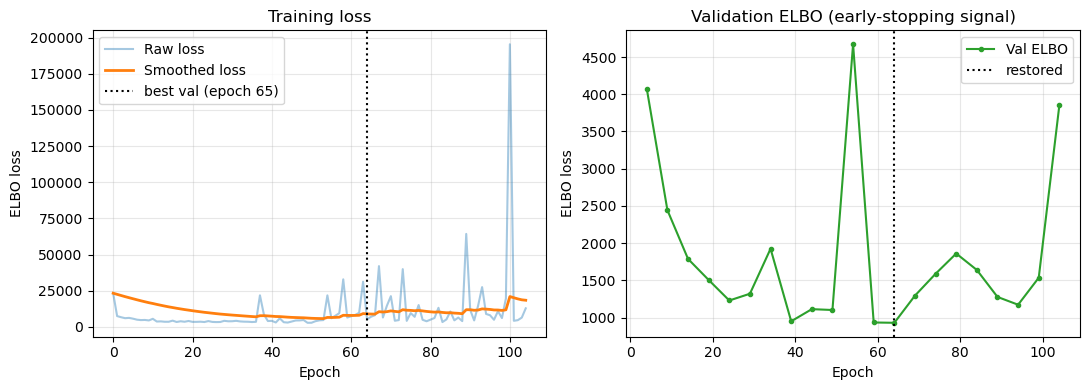

In [10]:
import pyro

# With early stopping the best-val checkpoint was already restored into the param
# store inside train_smooth_bnn, so this saves the best state, not the last epoch.
pyro.get_param_store().save(str(OUTPUT_DIR / 'targeted_bnn_params.pth'))

smoothed = []
for i, loss in enumerate(losses):
    smoothed.append(loss if i == 0 else 0.95 * smoothed[-1] + 0.05 * loss)

val_hist = getattr(model, 'val_losses_', [])
best_epoch = getattr(model, 'best_epoch_', -1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: training ELBO (raw + smoothed); dotted line = restored best-val epoch.
axes[0].plot(losses, alpha=0.4, label='Raw loss')
axes[0].plot(smoothed, lw=2, label='Smoothed loss')
if best_epoch >= 0:
    axes[0].axvline(best_epoch, color='k', ls=':', lw=1.5,
                    label=f'best val (epoch {best_epoch + 1})')
axes[0].set_title('Training loss')
axes[0].legend()

# Right: the early-stopping signal. Val ELBO falls, then flattens/turns up as the
# model starts overfitting; the dotted line marks where we rewound to. With early
# stopping off, fall back to the tail-zoom diagnostic instead.
if val_hist:
    ve, vl = zip(*val_hist)
    axes[1].plot(ve, vl, 'o-', color='tab:green', ms=3, label='Val ELBO')
    if best_epoch >= 0:
        axes[1].axvline(best_epoch, color='k', ls=':', lw=1.5, label='restored')
    axes[1].set_title('Validation ELBO (early-stopping signal)')
    axes[1].legend()
else:
    tail = max(len(losses) - 30, 0)
    axes[1].plot(range(tail, len(losses)), losses[tail:], alpha=0.4)
    axes[1].plot(range(tail, len(losses)), smoothed[tail:], lw=2)
    axes[1].set_title('Last 30 epochs')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('ELBO loss')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Calibrate on val, evaluate on test

Posterior predictions on the **val** split fit two corrections, both applied to test:

- **σ recalibration** — a single scalar for the predicted uncertainties (1.0 =
  already calibrated, < 1 = the raw uncertainties are inflated). The factor is the
  **robust** width of the val z-scores (1.4826·MAD, which equals the std for a
  Gaussian) rather than the plain std, so a handful of outlier stars cannot inflate
  it and de-calibrate everyone else; a large gap between the two estimates signals
  heavy tails rather than a wrong σ scale.
- **De-shrinkage via the inverse calibration fit** — fit `pred ≈ c·true + d` on val
  (σ-clipped) and invert: `pred' = (pred − d)/c`. The direction is deliberate:
  regressing `true` on `pred` is the MSE-optimal correction and *increases*
  shrinkage; the inverse fit is what makes E[pred'|true] track true, flattening
  the residual-vs-age trend at the cost of some extra scatter. It adds no
  information (rank order is unchanged) but removes the bias that matters for
  downstream old-vs-young comparisons. The debiased predictions get their own
  robust σ factor.

The **test** split is then evaluated once, reporting raw, calibrated, and debiased
coverage (targets: ~68% within 1σ, ~95% within 2σ). Each prediction is also flagged
if it falls outside the training logAge range — those stars are extrapolation
failures, not merely uncertain.

In [ ]:
def predict_split(*, X, X_err, y_err, y):
    # Keyword-only on purpose: y_err and y are adjacent same-shape float arrays,
    # so a positional swap would run silently and corrupt every metric downstream.
    X_t = to_tensor(X)
    X_err_t = to_tensor(X_err)
    y_err_t = to_tensor(y_err)
    samples, mean_pred, model_unc, intrinsic = get_targeted_posterior_samples(
        model, guide, X_t, X_err_t, y_err_t, num_samples=5000
    )
    return analyze_targeted_results(samples, mean_pred, model_unc, intrinsic, y_err, y)


print('=== VAL (calibration split) ===')
summary_val = predict_split(X=X_val, X_err=X_err_val, y_err=y_err_val, y=y_val)

# Scalar recalibration: if the uncertainties were right, z = residual/sigma would
# have unit width on val. Applied factor = robust width (1.4826*MAD == std for a
# Gaussian) so outlier stars cannot inflate it; compare with the plain std -- a
# big gap means heavy tails, which a scalar rescaling cannot fix.
z_val = summary_val['normalized_residual']
calib_std = float(z_val.std())
calib = float(1.4826 * (z_val - z_val.median()).abs().median())
print(f'\nCalibration factor (val): {calib:.3f} robust (applied)  |  {calib_std:.3f} plain std')
if abs(calib_std - calib) > 0.1 * calib:
    print('  NOTE: std and robust width disagree by >10% -> heavy-tailed z '
          'distribution; check the per-age calibration plot below.')

# De-shrinkage via the INVERSE calibration fit on val. Direction matters:
# regressing true on pred is the MSE-optimal correction and *increases*
# shrinkage (tried; it made the residual-vs-age trend worse). To make
# E[pred'|true] track true, fit pred ~ c*true + d and invert. Sigma-clipped so
# a single catastrophic prediction cannot tilt the line.
p_v = summary_val['pred_median'].values
t_v = summary_val['true_age'].values
keep = np.ones(len(p_v), dtype=bool)
for _ in range(3):
    c_cal, d_cal = np.polyfit(t_v[keep], p_v[keep], 1)
    fit_resid = p_v - (c_cal * t_v + d_cal)
    scale = 1.4826 * np.median(np.abs(fit_resid[keep] - np.median(fit_resid[keep])))
    if scale == 0:
        break
    keep = np.abs(fit_resid) < 3 * scale
a_cal = 1.0 / c_cal        # expressed as pred' = a*pred + b, the form
b_cal = -d_cal / c_cal     # the inference bundle consumes
z_val_db = pd.Series((t_v - (a_cal * p_v + b_cal))
                     / summary_val['total_predictive_uncertainty'].values)
calib_db = float(1.4826 * (z_val_db - z_val_db.median()).abs().median())
print(f'Inverse-calibration de-shrinkage (val, kept {int(keep.sum())}/{len(keep)} '
      f'after clipping): pred\' = {a_cal:.3f} * pred {b_cal:+.3f}; '
      f'debiased sigma factor {calib_db:.3f}')

print('\n=== TEST (held out, evaluated once) ===')
summary = predict_split(X=X_test, X_err=X_err_test, y_err=y_err_test, y=y_test)
summary.insert(0, 'APOGEE_ID', test[prep.ID_COL].values)   # traceability
summary['calibrated_uncertainty'] = summary['total_predictive_uncertainty'] * calib
summary['calibrated_z'] = summary['residual'] / summary['calibrated_uncertainty']
summary['pred_debiased'] = a_cal * summary['pred_median'] + b_cal
summary['residual_debiased'] = summary['true_age'] - summary['pred_debiased']
summary['debiased_uncertainty'] = summary['total_predictive_uncertainty'] * calib_db
summary['debiased_z'] = summary['residual_debiased'] / summary['debiased_uncertainty']

# Extrapolation flag: a median prediction outside the training label range means
# the network left the region the data constrains -- treat those stars as broken,
# not merely uncertain (see the worst-offender table below).
train_lo, train_hi = float(y_train.min()), float(y_train.max())
summary['pred_outside_train_range'] = ((summary['pred_median'] < train_lo) |
                                       (summary['pred_median'] > train_hi))
n_out = int(summary['pred_outside_train_range'].sum())
if n_out:
    print(f'\nWARNING: {n_out} test prediction(s) outside the training logAge '
          f'range [{train_lo:.2f}, {train_hi:.2f}]')

print('\nTest coverage (targets: 68% within 1 sigma, 95% within 2):')
for name, z in [('raw       ', summary['normalized_residual']),
                ('calibrated', summary['calibrated_z']),
                ('debiased  ', summary['debiased_z'])]:
    print(f'  {name}  |z|<1: {(z.abs() < 1).mean():6.1%}   |z|<2: {(z.abs() < 2).mean():6.1%}')

summary.to_csv(OUTPUT_DIR / 'targeted_prediction_summary.csv', index=False)
summary.head()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
xlim = (float(y_test.min()) - 0.05, float(y_test.max()) + 0.05)

# Left: density (hexbin) instead of saturated scatter.
hb = axes[0].hexbin(y_test, summary['pred_median'], gridsize=40, cmap='Blues',
                    mincnt=1, extent=(*xlim, *xlim))
fig.colorbar(hb, ax=axes[0], label='stars')
axes[0].plot(xlim, xlim, 'r--', lw=2)
axes[0].set_xlim(xlim)
axes[0].set_ylim(xlim)
axes[0].set_xlabel('True logAge')
axes[0].set_ylabel('Predicted logAge')
axes[0].set_title('Predictions vs True (test)')

# Right: residuals with binned medians before/after the de-shrinkage. The raw
# curve shows the regression-to-the-mean trend; the debiased curve should sit
# near zero across the age range if the val-fit correction transfers.
axes[1].scatter(y_test, summary['residual'], alpha=0.25, s=8, color='tab:blue')
axes[1].axhline(0, color='r', ls='--')
bin_ids = np.digitize(y_test, edges[1:-1])
for col, color, label in [('residual', 'k', 'binned median (raw)'),
                          ('residual_debiased', 'tab:green', 'binned median (debiased)')]:
    centers, medians = [], []
    for b in np.unique(bin_ids):
        m = bin_ids == b
        if m.sum() >= 5:
            centers.append(np.median(y_test[m]))
            medians.append(np.median(summary[col].values[m]))
    axes[1].plot(centers, medians, 'o-', color=color, lw=2, ms=4, label=label)

# Robust y-range: a single catastrophic prediction should not squash the panel.
# Clipped stars are counted here and listed in the worst-offender table below.
ylo, yhi = np.percentile(summary['residual'], [0.5, 99.5])
pad = 0.2 * (yhi - ylo)
ylo, yhi = ylo - pad, yhi + pad
n_clip = int(((summary['residual'] < ylo) | (summary['residual'] > yhi)).sum())
axes[1].set_ylim(ylo, yhi)
if n_clip:
    axes[1].annotate(f'{n_clip} star(s) beyond y-range (see worst-offender table)',
                     xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8, alpha=0.8)
axes[1].set_xlim(xlim)
axes[1].set_xlabel('True logAge')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('Residuals (test)')
axes[1].legend()

plt.tight_layout()
plt.show()

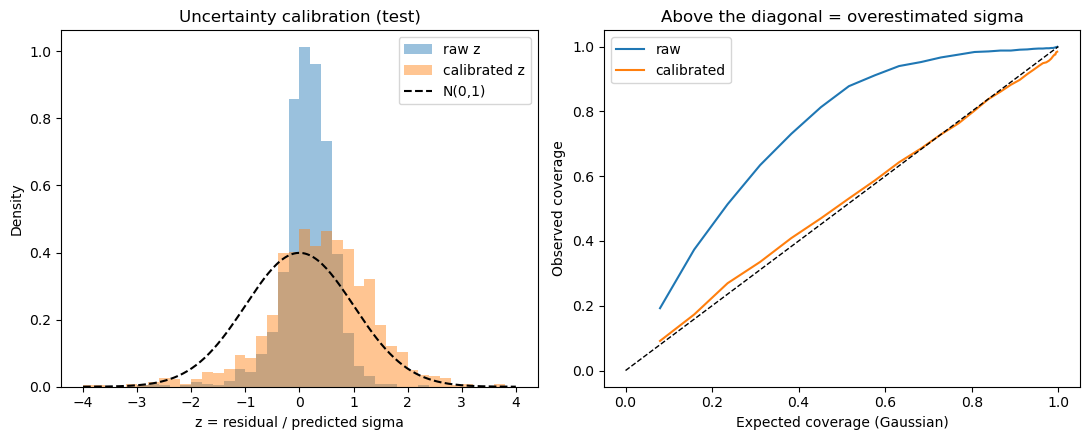

In [13]:
from math import erf

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# z-score histogram vs a unit normal
zgrid = np.linspace(-4, 4, 200)
axes[0].hist(summary['normalized_residual'], bins=40, range=(-4, 4), density=True,
             alpha=0.45, label='raw z')
axes[0].hist(summary['calibrated_z'], bins=40, range=(-4, 4), density=True,
             alpha=0.45, label='calibrated z')
axes[0].plot(zgrid, np.exp(-zgrid**2 / 2) / np.sqrt(2 * np.pi), 'k--', label='N(0,1)')
axes[0].set_xlabel('z = residual / predicted sigma')
axes[0].set_ylabel('Density')
axes[0].set_title('Uncertainty calibration (test)')
axes[0].legend()

# Coverage curve: fraction within k*sigma vs the Gaussian expectation
ks = np.linspace(0.1, 3.0, 30)
expected = np.array([erf(k / np.sqrt(2)) for k in ks])
for col, label in [('normalized_residual', 'raw'), ('calibrated_z', 'calibrated')]:
    observed = [(summary[col].abs() < k).mean() for k in ks]
    axes[1].plot(expected, observed, label=label)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Expected coverage (Gaussian)')
axes[1].set_ylabel('Observed coverage')
axes[1].set_title('Above the diagonal = overestimated sigma')
axes[1].legend()

plt.tight_layout()
plt.show()

### Calibration depth checks

Two questions the coverage numbers above cannot answer:

- **Is one scalar enough?** (left) The factor is fit globally on val; if the robust
  z width varies strongly with age, the tails need a per-age-bin factor instead.
- **Is σ informative?** (right) Coverage can be perfect with a constant σ. The
  per-star uncertainties only add value over a fixed error bar if larger predicted
  σ actually corresponds to larger errors — which is the BNN's whole justification
  over the point-estimate baselines in section 8.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: is one scalar enough? Robust width of the RAW val z-scores per age bin,
# against the applied factor. Bins far off the dotted line are mis-calibrated in
# a way no global scalar can fix (expect the sparse young/old tails first).
zv = summary_val['normalized_residual'].values
bin_ids_val = np.digitize(y_val, edges[1:-1])
centers, widths, counts = [], [], []
for b in np.unique(bin_ids_val):
    m = bin_ids_val == b
    if m.sum() >= 10:
        zb = zv[m]
        centers.append(np.median(y_val[m]))
        widths.append(1.4826 * np.median(np.abs(zb - np.median(zb))))
        counts.append(int(m.sum()))
axes[0].plot(centers, widths, 'o-', color='tab:blue', label='per-bin robust z width')
for x, w_, n in zip(centers, widths, counts):
    axes[0].annotate(str(n), (x, w_), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7, alpha=0.7)
axes[0].axhline(calib, color='k', ls=':', label=f'applied factor ({calib:.2f})')
axes[0].set_xlabel('True logAge (val)')
axes[0].set_ylabel('Robust std of raw z')
axes[0].set_title('Per-age calibration (val); counts above points')
axes[0].legend()

# Right: is sigma INFORMATIVE, not just calibrated on average? Coverage can hit
# 68/95 exactly with a constant sigma; the per-star uncertainties only add value
# if larger sigma actually predicts larger errors. For a Gaussian, the median
# |residual| at fixed sigma is 0.674*sigma.
sig = summary['calibrated_uncertainty'].values
absr = summary['residual'].abs().values
axes[1].scatter(sig, absr, alpha=0.25, s=8)
qs = np.quantile(sig, np.linspace(0, 1, 9))
mids, meds = [], []
for lo, hi in zip(qs[:-1], qs[1:]):
    m = (sig >= lo) & (sig <= hi)
    if m.sum() >= 5:
        mids.append(np.median(sig[m]))
        meds.append(np.median(absr[m]))
axes[1].plot(mids, meds, 'o-', color='k', lw=2, ms=4, label='binned median |resid|')
sgrid = np.linspace(sig.min(), sig.max(), 50)
axes[1].plot(sgrid, 0.6745 * sgrid, 'r--', label='Gaussian: 0.674σ')
rho = float(pd.Series(sig).rank().corr(pd.Series(absr).rank()))
axes[1].set_xlabel('Calibrated predicted σ (test)')
axes[1].set_ylabel('|residual|')
axes[1].set_title(f'σ informativeness (test): Spearman ρ = {rho:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Spearman rank correlation (predicted σ vs |residual|, test): {rho:.3f}')
print('~0 means σ carries no per-star information (only the average scale is right);')
print('the binned median tracking the red 0.674σ line means σ ranks stars correctly.')

### Worst-offender inspection

The residual panel showed at least one catastrophic prediction (several dex off).
Those stars dominate any non-robust statistic, so name them: the worst test stars
by |calibrated z|, with their raw features, plus a flag for predictions that left
the training logAge range entirely. Cross-check the IDs against the young-α-rich
audit list in section 4 — overlap means bad labels, not a bad model.

In [ ]:
# Ten worst test stars by |calibrated z|, with their raw features attached
# (test row order matches summary row order by construction). A cluster of
# extreme C_N / TEFF / low SNR here points at input-data problems; a lone
# wild prediction points at the network extrapolating.
worst_idx = summary['calibrated_z'].abs().nlargest(10).index
report = pd.concat(
    [summary.loc[worst_idx, ['APOGEE_ID', 'true_age', 'pred_median',
                             'calibrated_uncertainty', 'calibrated_z',
                             'pred_outside_train_range']],
     test.loc[worst_idx, ['TEFF', 'LOGG', 'FE_H', 'MG_FE', 'C_N', 'SNR']]],
    axis=1)
print(report.to_string(index=False,
                       float_format=lambda v: f'{v: .3f}'))
if n_out:
    print(f'\n{n_out} prediction(s) outside the training logAge range '
          f'[{train_lo:.2f}, {train_hi:.2f}] are flagged in '
          f"'pred_outside_train_range' (also saved in the summary CSV).")

## 8. Data-ceiling check

How close is the BNN to what these features can support? Two plain baselines
(closed-form ridge regression, inverse-distance-weighted kNN) run on the **identical**
split and features.

How to read the numbers:

- If a baseline beats the BNN on correlation/RMS, there is **headroom** — the features
  hold signal the BNN is not extracting, so training/architecture (not the data) is
  the limit.
- Slope < 1 is regression toward the mean. The inverse-frequency age weighting
  deliberately trades some RMS for a slope closer to 1, so the BNN can legitimately
  show worse RMS but a much better slope than an unweighted baseline. Decide which
  matters for the science before "fixing" either.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor


def _metrics(y, p):
    return (float(np.corrcoef(y, p)[0, 1]),
            float(np.sqrt(np.mean((y - p) ** 2))),
            float(np.polyfit(y, p, 1)[0]))


# Ridge regression (closed form, small penalty; the intercept is not penalized)
A = np.hstack([X_train, np.ones((len(X_train), 1))])
At = np.hstack([X_test, np.ones((len(X_test), 1))])
penalty = 1e-2 * np.eye(A.shape[1])
penalty[-1, -1] = 0.0
coef = np.linalg.solve(A.T @ A + penalty, A.T @ y_train)
ridge_pred = At @ coef

# Inverse-distance-weighted kNN
d = np.sqrt(((X_test[:, None, :] - X_train[None, :, :]) ** 2).sum(-1))
nn = np.argsort(d, axis=1)[:, :10]
dd = np.take_along_axis(d, nn, axis=1)
wts = 1.0 / (dd + 1e-6)
wts /= wts.sum(axis=1, keepdims=True)
knn_pred = (y_train[nn] * wts).sum(axis=1)

# Gradient-boosted trees: close to the practical ceiling for a handful of
# tabular features, so this is the strongest "is there headroom?" referee.
gbt = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05,
                                    early_stopping=True, random_state=SEED)
gbt.fit(X_train, y_train)
gbt_pred = gbt.predict(X_test)

results = {name: _metrics(y_test, p)
           for name, p in [('ridge', ridge_pred),
                           ('kNN k=10', knn_pred),
                           ('GBT', gbt_pred),
                           ('BNN', summary['pred_median'].values),
                           ('BNN debiased', summary['pred_debiased'].values)]}
print(f"{'model':12s} {'corr':>6s} {'RMS':>7s} {'slope':>7s}   (test, n={len(y_test)})")
for name, (c, r, s) in results.items():
    print(f'{name:12s} {c:6.3f} {r:7.3f} {s:7.3f}')
print(f"{'mean-only':12s} {'--':>6s} {y_test.std():7.3f} {0.0:7.3f}   (predict-the-mean floor)")

# Verdict driven by the numbers, not asserted. The debiased row shares the BNN's
# corr (an affine map cannot change rank order) but shows the slope fix; RMS can
# go up in the dense bulk -- that is the price of unbiased tails.
BASELINES = ('ridge', 'kNN k=10', 'GBT')
bnn_c, bnn_r, bnn_s = results['BNN']
base_c = max(results[b][0] for b in BASELINES)
base_r = min(results[b][1] for b in BASELINES)
print()
if bnn_c >= base_c - 0.01 and bnn_r <= base_r + 0.01:
    print('BNN matches or beats the baselines => it is extracting what the features')
    print('hold; further gains need better labels or features, not more training.')
else:
    print(f'A baseline beats the BNN on point accuracy (corr {base_c:.3f} vs {bnn_c:.3f}, '
          f'RMS {base_r:.3f} vs {bnn_r:.3f}) => headroom remains.')
    print(f'Note the BNN slope ({bnn_s:.3f}) vs the baselines: the age weighting')
    print('deliberately trades RMS for less regression to the mean.')

In [ ]:
import joblib

# Everything needed to reproduce predictions, in one bundle next to the param
# store. NOTE: the learned posterior lives in the Pyro param store
# (targeted_bnn_params.pth, saved in section 6) -- model.state_dict() alone
# cannot restore a Pyro BNN, so no state_dict is saved.
bundle = {
    'features': FEATURES,
    'stats': stats,                 # per-feature {"mean","std"} from TRAIN only
    'y_mean': y_mean,
    'y_std': y_std,
    'model_kwargs': MODEL_KWARGS,   # re-instantiate the identical architecture
    'age_bin_edges': edges,
    'weight_clip': WEIGHT_CLIP,
    'seed': SEED,
    'calibration_factor': calib,    # robust (1.4826*MAD) val z width; multiply predicted sigmas by this
    'calibration_factor_std': calib_std,  # plain val z std, for reference/diagnostics
    # De-shrinkage from the sigma-clipped INVERSE calibration fit on val
    # (pred ~ c*true + d, inverted). To use debiased point predictions at
    # inference: pred' = a*pred + b, sigma' = raw_sigma * sigma_factor.
    'affine_debias': {'a': float(a_cal), 'b': float(b_cal),
                      'sigma_factor': calib_db},
    # Predictions outside this logAge range are extrapolation failures; flag them.
    'train_label_range': [train_lo, train_hi],
    'param_store_file': 'targeted_bnn_params.pth',
}
joblib.dump(bundle, OUTPUT_DIR / 'bnn_inference_bundle_rgb.pkl')
print(f"Saved {OUTPUT_DIR / 'bnn_inference_bundle_rgb.pkl'}")

# The reload recipe is not just documented -- the next cell executes it and
# asserts the reloaded model reproduces the in-memory predictions.

## 9. Verify the bundle & record the run

The saved bundle is only useful if the reload path actually reproduces the trained
model — so run it, don't just document it. Then write a `run_manifest.json`
capturing config, code version, environment, and headline metrics, so runs can be
compared weeks apart without re-opening notebook outputs.

In [ ]:
from pyro.infer.autoguide import AutoDiagonalNormal

# Round-trip check in two layers:
#  (1) EXACT -- every tensor in the reloaded param store equals what the
#      in-memory store holds; deterministic, catches any save-format drift.
#  (2) BEHAVIORAL -- a fresh model+guide built from the bundle (the exact
#      recipe predict_bulge_ages.py uses) reproduces the posterior mean
#      predictions under the same seed.
# The fresh guide is hydrated BEFORE the seeded runs: its lazy setup consumes
# RNG draws, and comparing runs with shifted RNG streams turns the check into
# a Monte-Carlo comparison that can differ by whole dex for extreme stars
# (verified: with hydration first, the two runs match bit-for-bit).
#
# Note: pyro.clear_param_store() wipes the store the in-memory `guide` also
# reads from, but layer (1) proves the reload restored identical values under
# identical names, so the original model/guide keep working after this cell.

n_check = 20
Xc = to_tensor(X_val[:n_check])
Xc_err = to_tensor(X_err_val[:n_check])
yc_err = to_tensor(y_err_val[:n_check])

trained_params = {name: p.detach().cpu().clone()
                  for name, p in pyro.get_param_store().named_parameters()}

b = joblib.load(OUTPUT_DIR / 'bnn_inference_bundle_rgb.pkl')
model_rt = BayesianNeuralNetwork(**b['model_kwargs']).to(device)
pyro.clear_param_store()
# ParamStore.load calls torch.load with its weights_only=True default (torch
# >= 2.6), which rejects the constraint objects Pyro pickles into the
# checkpoint. This file was written by this notebook moments ago, so loading
# it with weights_only=False is safe -- same recipe as predict_bulge_ages.py.
state = torch.load(str(OUTPUT_DIR / b['param_store_file']),
                   map_location=device, weights_only=False)
pyro.get_param_store().set_state(state)

# (1) exact comparison
loaded_params = {name: p.detach().cpu()
                 for name, p in pyro.get_param_store().named_parameters()}
assert set(loaded_params) == set(trained_params), (
    f'Param names differ after reload: '
    f'missing={sorted(set(trained_params) - set(loaded_params))}, '
    f'extra={sorted(set(loaded_params) - set(trained_params))}')
max_param_diff = max((trained_params[n] - loaded_params[n]).abs().max().item()
                     for n in trained_params)
assert max_param_diff <= 1e-8, (
    f'Reloaded params differ from trained ones: max |delta| = {max_param_diff:.2e}')
print(f'Param store round-trip exact: {len(loaded_params)} tensors, '
      f'max |delta| = {max_param_diff:.1e}')

# (2) behavioral comparison, RNG-stream-aligned
guide_rt = AutoDiagonalNormal(model_rt)
guide_rt(Xc, Xc_err)   # hydrate: setup's RNG draws happen before the seeding

set_seed(SEED)
_, ref_pred, _, _ = get_targeted_posterior_samples(
    model, guide, Xc, Xc_err, yc_err, num_samples=500)
set_seed(SEED)
_, rt_pred, _, _ = get_targeted_posterior_samples(
    model_rt, guide_rt, Xc, Xc_err, yc_err, num_samples=500)

max_diff = float(np.max(np.abs(ref_pred.mean(axis=0) - rt_pred.mean(axis=0))))
assert max_diff < 1e-4, (
    f'Bundle round-trip FAILED: max |delta mean pred| = {max_diff:.2e} -- the '
    'reloaded model does not reproduce the trained model.')
print(f'Bundle round-trip OK: max |delta mean pred| = {max_diff:.2e} dex '
      f'over {n_check} val stars (fresh model + guide, params reloaded from disk).')

In [ ]:
import json
import platform
import subprocess
from datetime import datetime, timezone

# One JSON per run answering "what produced these artifacts?": config, code
# version, environment, and headline metrics. Cheap insurance for comparing
# Gadi runs weeks apart without re-opening the notebook outputs.
_git = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=repo,
                      capture_output=True, text=True)
_git_dirty = subprocess.run(['git', 'status', '--porcelain'], cwd=repo,
                            capture_output=True, text=True)

manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'git_commit': _git.stdout.strip() or None,
    'git_dirty': bool(_git_dirty.stdout.strip()),
    'dataset': DATASET,
    'age_labels': 'Willett age_L (log10), Cannon-notebook selection',
    'selection_file': str(SELECTION_FILE) if SELECTION_FILE else None,
    'n_train': int(len(train)), 'n_val': int(len(val)), 'n_test': int(len(test)),
    'config': {
        'TEST_FRAC': TEST_FRAC, 'VAL_FRAC': VAL_FRAC, 'SEED': SEED,
        'NUM_ITERATIONS': NUM_ITERATIONS, 'BATCH_SIZE': BATCH_SIZE,
        'HIDDEN_DIM': HIDDEN_DIM, 'INITIAL_LR': INITIAL_LR,
        'LR_DECAY_PER_EPOCH': LR_DECAY_PER_EPOCH, 'WEIGHT_CLIP': WEIGHT_CLIP,
        'INTRINSIC_PRIOR_SCATTER': INTRINSIC_PRIOR_SCATTER,
        'INTRINSIC_PRIOR_LOGSTD': INTRINSIC_PRIOR_LOGSTD,
        'EARLY_STOPPING': EARLY_STOPPING, 'ES_PATIENCE': ES_PATIENCE,
        'ES_MIN_DELTA': ES_MIN_DELTA, 'ES_EVAL_EVERY': ES_EVAL_EVERY,
        'YOUNG_LOGAGE': YOUNG_LOGAGE, 'ALPHA_RICH_MGFE': ALPHA_RICH_MGFE,
        'features': FEATURES,
    },
    'training': {
        'best_epoch': int(best_epoch),
        'stopped_epoch': int(getattr(model, 'stopped_epoch_', -1)),
        'epochs_run': len(losses),
    },
    'calibration': {'factor_applied_robust': calib, 'val_z_std': calib_std},
    'affine_debias': {'a': float(a_cal), 'b': float(b_cal), 'sigma_factor': calib_db,
                      'fit': 'inverse-calibration, sigma-clipped, val'},
    'test_metrics': {
        'corr': results['BNN'][0],
        'rms': results['BNN'][1],
        'slope': results['BNN'][2],
        'cov_1sigma_raw': float((summary['normalized_residual'].abs() < 1).mean()),
        'cov_2sigma_raw': float((summary['normalized_residual'].abs() < 2).mean()),
        'cov_1sigma_calibrated': float((summary['calibrated_z'].abs() < 1).mean()),
        'cov_2sigma_calibrated': float((summary['calibrated_z'].abs() < 2).mean()),
        'sigma_absresid_spearman': rho,
        'n_pred_outside_train_range': n_out,
    },
    'test_metrics_debiased': {
        'corr': results['BNN debiased'][0],
        'rms': results['BNN debiased'][1],
        'slope': results['BNN debiased'][2],
        'cov_1sigma': float((summary['debiased_z'].abs() < 1).mean()),
        'cov_2sigma': float((summary['debiased_z'].abs() < 2).mean()),
    },
    'baselines': {name: dict(zip(('corr', 'rms', 'slope'), m))
                  for name, m in results.items()
                  if name not in ('BNN', 'BNN debiased')},
    'versions': {
        'python': platform.python_version(),
        'numpy': np.__version__, 'pandas': pd.__version__,
        'torch': torch.__version__, 'pyro': pyro.__version__,
    },
    'artifacts': ['targeted_bnn_params.pth', 'bnn_inference_bundle_rgb.pkl',
                  'targeted_prediction_summary.csv', 'split_assignments.csv'],
}
with open(OUTPUT_DIR / 'run_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"Saved {OUTPUT_DIR / 'run_manifest.json'}")
print(json.dumps(manifest['test_metrics'], indent=2))
print(json.dumps(manifest['test_metrics_debiased'], indent=2))